In [1]:
# This code works in Python 3.10.6
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import torch_geometric.transforms as T
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
from torch_geometric.datasets import IMDB
import os
import os.path as osp

In [3]:
def get_selected_features(X):

    col_sum = X.sum(axis=0)
    sorted_colsum = sorted(col_sum, reverse=True)
    colsum_df = pd.DataFrame(col_sum)
    
    sorted_colsum = sorted(col_sum, reverse=True)[:2]
    index_list = list(np.ravel(colsum_df[colsum_df[0].isin(sorted_colsum)].index))
    
    imp_feat = X[index_list]

    return imp_feat

## IMDB

In [4]:
dataset = IMDB(root='./imdb_data')
data = dataset[0]
data

HeteroData(
  movie={
    x=[4278, 3066],
    y=[4278],
    train_mask=[4278],
    val_mask=[4278],
    test_mask=[4278],
  },
  director={ x=[2081, 3066] },
  actor={ x=[5257, 3066] },
  (movie, to, director)={ edge_index=[2, 4278] },
  (movie, to, actor)={ edge_index=[2, 12828] },
  (director, to, movie)={ edge_index=[2, 4278] },
  (actor, to, movie)={ edge_index=[2, 12828] }
)

In [5]:
dataset = IMDB(root='./imdb_data')
data = dataset[0]
movie = data['movie'].x.tolist()
df = pd.DataFrame(movie)
df['class'] = data['movie'].y.tolist()

### Bag-of-Words features of Movie node

In [6]:
# Feature selection for Movie class 0
class0 = df[df['class'] == 0].drop(['class'], axis=1)
X = class0
imp_feat0 = get_selected_features(class0)
imp_feat0.head()

,2095,2746
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,1.0,0.0
4,0.0,0.0


In [7]:
# Feature selection for Movie class 1
class1 = df[df['class'] == 1].drop(['class'], axis=1)
X = class1
imp_feat1 = get_selected_features(class1)
imp_feat1.head()

,1111,1381
6,0.0,0.0
29,0.0,1.0
34,1.0,0.0
36,0.0,0.0
47,0.0,0.0


In [8]:
# Feature selection for Movie class 2
class2 = df[df['class'] == 2].drop(['class'], axis=1)
X = class2
imp_feat2 = get_selected_features(class2)
imp_feat2.head()

,1624,1900
21,1.0,0.0
42,0.0,0.0
52,0.0,0.0
60,0.0,0.0
69,0.0,0.0


In [9]:
def sample_features(model,node_type, n_samples):

    smpls = model.sample(n_samples)
    print("no of class {} node samples - {}".format(node_type, n_samples))
    return smpls[0]

In [10]:
def fit_sample_gm(df_class, node_type, n_samples):
    #fit
    model = GaussianMixture(n_components=1, covariance_type='full', random_state = 0)
    model.fit(df_class)

    #sample
    smpls = sample_features(model, node_type, n_samples)
    new_features_dict[node_type] = smpls

In [11]:
def cosine_sim(original,sampled):
    return cosine_similarity(np.array(original), np.array(sampled))

### Fit Gaussian Mixture Models to 3 Movie node classes

In [12]:
new_features_dict = {}

In [13]:
fit_sample_gm(imp_feat0, 'movie0', imp_feat0.shape[0])
fit_sample_gm(imp_feat1, 'movie1', imp_feat1.shape[0])
fit_sample_gm(imp_feat2, 'movie2', imp_feat2.shape[0])

no of class movie0 node samples - 1135
no of class movie1 node samples - 1584
no of class movie2 node samples - 1559


### Continuous features sampled using Gaussian Mixure Models

In [14]:
sampled0  = pd.DataFrame(new_features_dict['movie0'])
sampled0.head()

,0,1
0,-0.526498,-0.045123
1,-0.447428,0.524238
2,-0.429333,-0.413924
3,-0.211380,-0.091627
4,0.075460,0.178405


In [15]:
sampled1  = pd.DataFrame(new_features_dict['movie1'])
sampled1.head()

,0,1
0,0.104771,0.667996
1,0.671343,0.499127
2,-0.294374,0.638555
3,-0.011183,0.380927
4,0.203499,0.067559


In [16]:
sampled2  = pd.DataFrame(new_features_dict['movie2'])
sampled2.head()

,0,1
0,0.151470,0.702943
1,0.658786,0.443483
2,-0.220968,0.724417
3,0.015052,0.406445
4,0.182011,0.037064


### Sampled continuous features are converted to discrete using a threshold

In [17]:
sampled_discrete_class0 = pd.DataFrame(sampled0).applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.75>=x<0.8 
                       else 2.0 if 0.8>=x<0.85 else 3.0 if 0.85>=x<0.9 
                       else 5.0 if 0.95>=x<0.99 else 0.0)
sampled_discrete_class0.head()

,0,1
0,0.0,0.0
1,0.0,1.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [18]:
sampled_discrete_class1 = pd.DataFrame(sampled1).applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.75>=x<0.8 
                       else 2.0 if 0.8>=x<0.85 else 3.0 if 0.85>=x<0.9  else 0.0)
sampled_discrete_class1.head()

,0,1
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,0.0,0.0
4,0.0,0.0


In [19]:
sampled_discrete_class2 = pd.DataFrame(sampled2).applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.75>=x<0.8 
                       else 2.0 if 0.8>=x<0.85 else 3.0 if 0.85>=x<0.9  else 0.0)
sampled_discrete_class2.head()

,0,1
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,0.0,0.0
4,0.0,0.0


### Pairwise cosine similarity of all features for real and synthetic distributions

Movie class 0

In [20]:
cosine_sim(imp_feat0,sampled_discrete_class0)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [21]:
sns.set(font_scale=1.4)

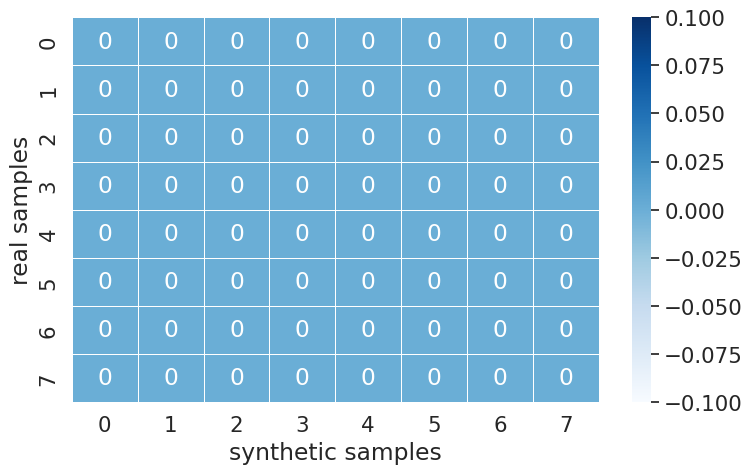

In [22]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(imp_feat0.iloc[:8],sampled_discrete_class0[:8]),xticklabels = 1, yticklabels = 1, 
            cmap='Blues', annot=True,linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [23]:
#Average cosine similarity for class 0
avg_cossim_class0 = np.mean(cosine_sim(imp_feat0,sampled_discrete_class0))
avg_cossim_class0

0.009939408010132678

Movie class 1

In [24]:
cosine_sim(imp_feat1,sampled_discrete_class1)

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

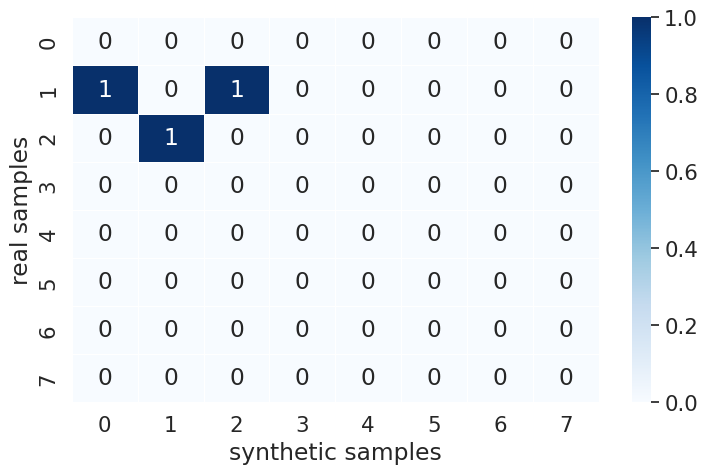

In [25]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(imp_feat1.iloc[:8],sampled_discrete_class1[:8]),xticklabels = 1, yticklabels = 1, 
            cmap='Blues', annot=True,linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [26]:
#Average cosine similarity for class 1
avg_cossim_class1 = np.mean(cosine_sim(imp_feat1,sampled_discrete_class1))
avg_cossim_class1

0.010421062416878825

Movie class 2

In [27]:
cosine_sim(imp_feat2,sampled_discrete_class2)

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

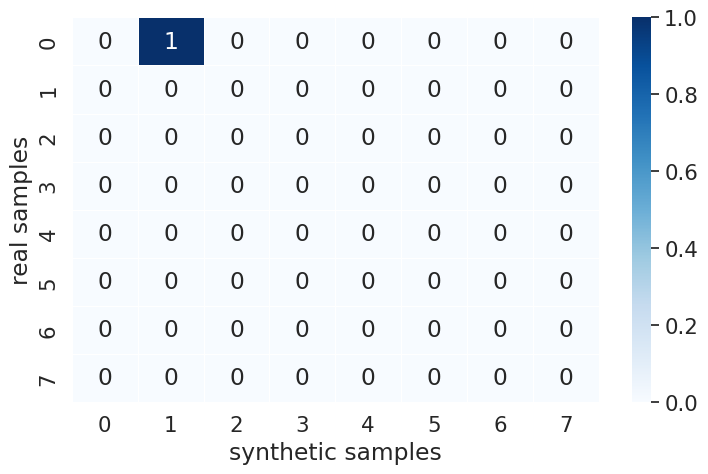

In [28]:
fig, ax = plt.subplots(figsize=(8.5,5))
sns.heatmap(cosine_sim(imp_feat2.iloc[:8],sampled_discrete_class2[:8]),xticklabels = 1, yticklabels = 1, 
            cmap='Blues', annot=True,linewidth=.5)
plt.xlabel("synthetic samples") 
plt.ylabel("real samples") 
plt.show()

In [29]:
#Average cosine similarity for class 2
avg_cossim_class2 = np.mean(cosine_sim(imp_feat2,sampled_discrete_class2))
avg_cossim_class2

0.006874219195408411

Average cosine similarity for all classes

In [30]:
(avg_cossim_class0 + avg_cossim_class1 +avg_cossim_class2)/3

0.00907822987413997